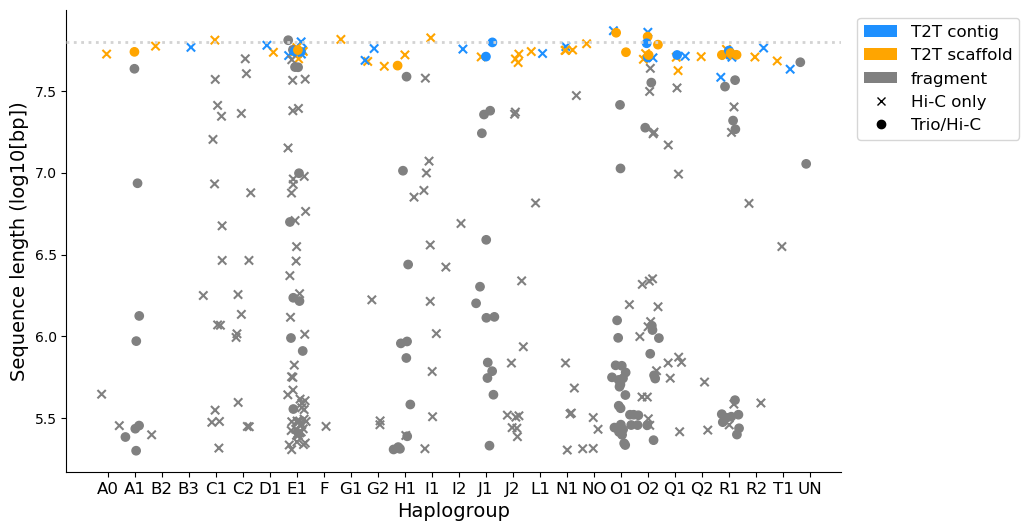

In [93]:
import pathlib as pl
import collections as col

import pandas as pd
import numpy as np

import numpy.random as rng
rng.seed()

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

seq_rename_file = CONFIG["project_repo"].joinpath(
    "codebase/extract-sex-chromosomes/workflow/results",
    "seq_rename_composition.tsv.gz"
)

def assign_sex(table):

    select_males = table["chromosome"] == "chrY"
    male_samples = table.loc[select_males, "sample"].values
    table["sample_sex"] = "female"
    table.loc[table["sample"].isin(male_samples), "sample_sex"] = "male"
    return None

rename_table = pd.read_csv(seq_rename_file, sep="\t", header=0, comment="#")
rename_table["contiguity"] = rename_table["name"].apply(lambda n: n.split("|")[-1])
rename_table["assembly_type"] = rename_table["name"].apply(lambda n: "hic" if n.split("|")[3] == "UNK" else "thc")
rename_table["haplogroup"] = rename_table["name"].apply(lambda n: n.split("|")[2])
assign_sex(rename_table)


def add_jitter(coord):

    slack = rng.normal(0, 0.2)
    return coord+slack

    


def male_size_dist(table):


    male_subset = table.loc[table["chromosome"] == "chrY", :].copy()
    male_subset["log_len"] = np.log10(male_subset["seq_length"])

    haplogroups = sorted(set(male_subset["haplogroup"].values))
    hg_idx = dict((hg, pos) for pos, hg in enumerate(haplogroups, start=1))

    colormap = {
        "CTG": "dodgerblue",
        "SCF": "orange",
        "FRG": "gray"
    }

    points = {
        "hic": col.defaultdict(list),
        "thc": col.defaultdict(list)
    }
    
    for sample, seqs in male_subset.groupby("sample"):

        atype = seqs["assembly_type"].iloc[0]
        for seq in seqs.itertuples():
            x_val = hg_idx[seq.haplogroup]
            points[atype]["x_vals"].append(add_jitter(x_val))
            points[atype]["y_vals"].append(seq.log_len)
            color = colormap[seq.contiguity]
            points[atype]["color"].append(color)

    fig, ax = plt.subplots(figsize=(10,6))

    ax.scatter(
        points["hic"]["x_vals"],
        points["hic"]["y_vals"],
        marker="x",
        label="HiC",
        c=points["hic"]["color"]
    )

    ax.scatter(
        points["thc"]["x_vals"],
        points["thc"]["y_vals"],
        marker="o",
        label="Trio/HiC",
        c=points["thc"]["color"]
    )

    x_pos = [hg_idx[hg] for hg in haplogroups]
    x_labels = haplogroups

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=12)

    ax.set_ylabel("Sequence length (log10[bp])", fontsize=14)
    ax.set_xlabel("Haplogroup", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    custom_handles = [
        patches.Patch(facecolor='dodgerblue', edgecolor=None, label='T2T contig'),
        patches.Patch(facecolor='orange', edgecolor=None, label='T2T scaffold'),
        patches.Patch(facecolor='gray', edgecolor=None, label='fragment'),
        lines.Line2D([], [], ls="None", color='black', marker="x", label='Hi-C only'),
        lines.Line2D([], [], ls="None", color='black', marker="o", label='Trio/Hi-C'),
    ]

    ax.legend(handles=custom_handles, bbox_to_anchor=(1.01,1.), fontsize=12)

    ax.axhline(np.log10(62460029), 0, 1, lw=2, ls="dotted", zorder=3, color="lightgrey")

    plt.savefig("size_dist.png", dpi=300, bbox_inches="tight")
    
    return


male_size_dist(rename_table)
    
        
            
    